In [94]:
from pathlib import Path
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import seaborn as sns

results_dir = Path("../data/processed_data")
results_dir.mkdir(exist_ok=True)

In [173]:
amps = pd.read_table("../data/raw_data/alignments/Stats/coverage.txt", sep="\t")

amps_reshaped = (
    amps
    .melt(
        id_vars=amps.columns[:2],
        value_vars=amps.columns[2:],
        var_name="GENE",
        value_name="VALUES"
    )
    .pivot(
        index=["SAMPLE", "GENE"],
        columns="METRIC",
        values="VALUES"
    )
    .reset_index()
)

amps_reshaped["GENE"] = amps_reshaped["GENE"].map({
    "RPOB": "rpoB",
    "GYRA": "gyrA",
    "GYRB": "gyrB",
    "FOLP1": "folP1",
    "FOLP2": "folP2",
    "23S_RNA_I": "23S rRNA I",
    "23S_RNA_II": "23S rRNA II"
})

amps_reshaped["SAMPLE"] = (
    amps_reshaped["SAMPLE"]
    .astype("category")
    .cat.rename_categories([f"Sample {i}" for i in range(1, 10)])
)

amps_reshaped.to_csv("../data/processed_data/coverage.csv", index=False)

amps_reshaped.head()

METRIC,SAMPLE,GENE,FDEPTH,FPCOV-1,FREADS,FRPERC,FVDEPTH,READSIZE
0,Sample 1,23S rRNA I,7191.3,100.0,7452.0,16.218,6867.0,NaN
1,Sample 1,23S rRNA II,5087.4,100.0,5463.0,11.890,4674.0,NaN
2,Sample 1,folP1,12910.6,100.0,13697.0,29.810,12512.0,NaN
3,Sample 1,folP2,1045.8,100.0,1392.0,3.030,820.0,NaN
4,Sample 1,gyrA,8419.8,100.0,9181.0,19.981,7559.0,NaN


# Global sequencing metrics

In [128]:
cov_heatmap = (
    amps_reshaped
    .loc[:, ["SAMPLE", "GENE", "FDEPTH"]]
    .pivot(
        index="SAMPLE",
        columns="GENE",
        values="FDEPTH"
    )
    .apply(np.log10)
)

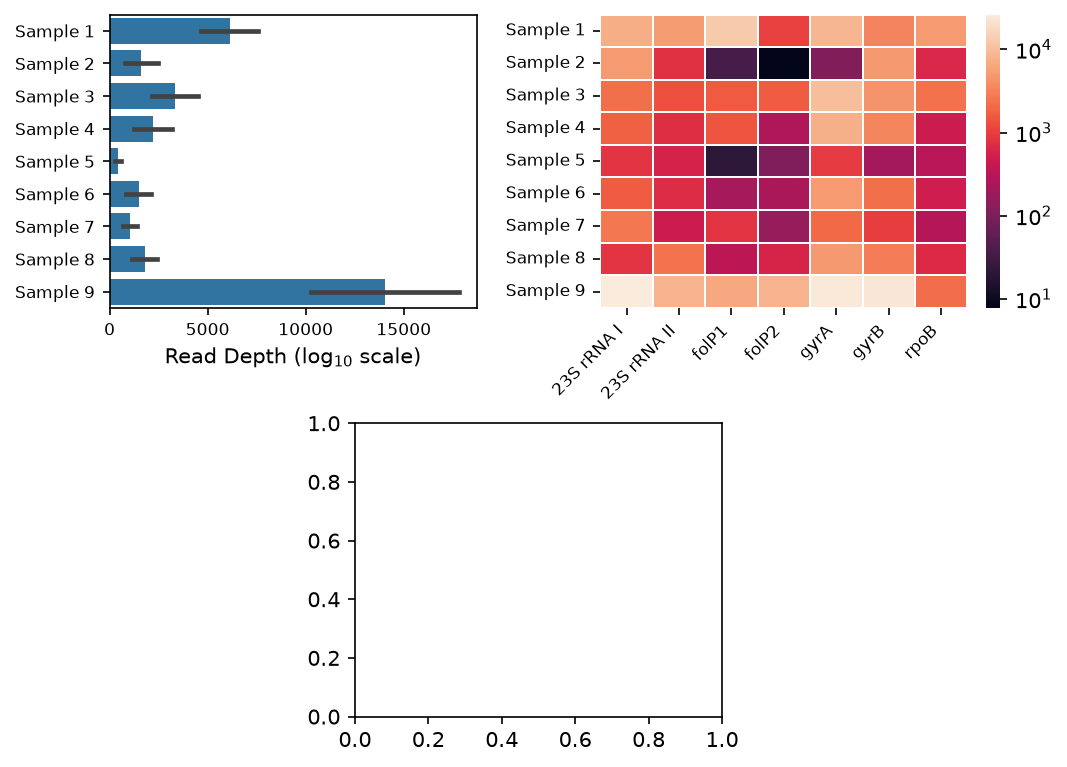

In [172]:
fig = plt.figure(figsize=(7,5), dpi=150, layout="constrained")

gs = GridSpec(nrows=2, ncols=4, figure=fig)

ax1 = fig.add_subplot(gs[0,:-2])
ax2 = fig.add_subplot(gs[0,2:])
ax3 = fig.add_subplot(gs[1,1:3])

sns.barplot(amps_reshaped, x="FDEPTH", y="SAMPLE", errorbar="se", ax=ax1)

ax1.set_ylabel(None)
ax1.set_xlabel(r"Read Depth (log$_{10}$ scale)", size=10)
plt.setp(ax1.get_xticklabels(), size=8)
plt.setp(ax1.get_yticklabels(), size=8)

sns.heatmap(cov_heatmap, linewidth=0.75, ax=ax2)

ax2.set_ylabel(None)
ax2.set_xlabel(None)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", size=8)
plt.setp(ax2.get_yticklabels(), size=8)

cbar = ax2.collections[0].colorbar
cbar.set_ticks([1, 2, 3, 4])
cbar.set_ticklabels([r"10$^{1}$", r"10$^{2}$", r"10$^{3}$", r"10$^{4}$"])

plt.show()